<center>
<a href="https://nxv.fr"> <img src="https://nxv.fr/img/logo-NXV-fondtransparent.png" width="400"> </a>
</center>




# 🧠 Créez votre premier réseau de neurones !

L'intelligence artificielle est définie comme toute simulation du comportement humain par une machine. Dans ce notebook nous allons construire un modèle capable de différencier des images. Comme on parle de tri, on peut regarder cet [extrait de Wall-E](https://www.youtube.com/watch?v=QHH3iSeDBLo) avant de commencer.

De nos jours, les modèles d'IA les plus performants s'inspirent de la biologie et des neurones.

Pour le démontrer, nous allons utiliser le langage Python et le module [TensorFlow](https://www.tensorflow.org/), une librairie open-source très populaire pour l'apprentissage artificiel. 

Nous allons charger cette librairie et mettre en place le notebook avec les instructions suivantes. 

Pour exécuter ce code, cliquez sur la cellule et appuyez sur les touches `Ctrl` et `Entrée` en même temps.


In [ ]:
import tensorflow as tf
import os

# Chargement du matériel dans Colab
if "COLAB_GPU" in os.environ:

    !git clone https://github.com/NXV-Formation/mon_premier_reseau_neuronal/Mon_premier_reseau_neuronal.git
    %cd mon_premier_reseau_neuronal



## 🐈🐕🐎 Données

Nous allons traiter d'un sujet sur la reconnaissance ou classification d'images par apprentissage artificiel. Plus précisément, nous allons utiliser une base d'images d'animaux.

Les réseaux de neurones copient les capacités d'apprentissage de l'être humain, par essais / erreurs. Pour ce faire, nous allons faire apprendre à la machine quel animal est présent dans chaque image, en lui présentant la bonne réponse, pour qu'elle corrige ses erreurs.

Avec la cellule ci-dessous, nous allons charger cette base d'images.


In [ ]:
# chargement du jeu de données
dataset_animals = tf.keras.preprocessing.image_dataset_from_directory("data", 
                                                                      image_size=(128, 128),
                                                                      batch_size=1,
                                                                      shuffle=True)

class_names = dataset_animals.class_names
# on affiche les classes à apprendre
print(class_names)


Notre jeu de données contient des images et leur réponse associée. En général, on utilise le mot `label` (étiquette) pour la réponse attendue.

On peut afficher une image tirée au hasard dans le jeu de données. Pour ce faire, nous allons utiliser le module [Matplotlib](https://matplotlib.org/) et le code suivant. 

In [ ]:
import matplotlib.pyplot as plt

for images, labels in dataset_animals.take(1):

    image = images[0].numpy().astype("uint8")
    label = labels[0].numpy()

    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

Qu'est ce que l'on cherche à reconnaître ? Voici la liste des catégories d'animaux de notre base :

| Label | Description (en) | Description (fr) |
| --- | --- | --- |
| 0 | Cat | Chat |
| 1 | Dog | Chien |
| 2 | Horse | Cheval |


## 🛠️ Construire des neurones artificiels

Les neurones sont des unités fondamentales pour construire des réseaux neuronaux. Comme les neurones biologiques émettent des signaux électriques sous l'effet d'une stimulation, les neurones artificiels calculent une valeur numérique en fonction de leurs entrées.

On peut séparer le fonctionnement d'un réseau de neurones artificiel en 3 étapes :
- Définir l'architecture
- Lancer l'entrainement (apprentissage)
- Evaluer (tester) le réseau

### Définir l'architecture
<center>
<a title="Nicolas.Rougier, CC BY 4.0 &lt;https://creativecommons.org/licenses/by/4.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Neuron-figure-fr.svg"><img width="250" alt="Neuron-figure-fr" src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/19/Neuron-figure-fr.svg/250px-Neuron-figure-fr.svg.png"></a>
<p><small>
Schéma d'un neurone. Issu de <a href="https://fr.wikipedia.org/wiki/Neurone">Wikipedia</a>
</small></p>
</center>

Les neurones biologiques transmettent les informations suivant un certain [code](https://fr.wikipedia.org/wiki/Codage_neuronal). Ils reçoivent des signaux électriques suivant les dendrites, et suivant certaines conditions, émettent une impulsion par l'axone et ses terminaisons.

Il est convenu que les séquences et le rythme de ces impulsions jouent un rôle important dans la transmission de l'information dans le cerveau. La plupart des réseaux de neurones artificiels cherchent à capturer ces aspects des "vrais" neurones, et émulent le phénomène par des formules mathématiques simples.


### Les maths derrière les neurones

Les ordinateurs sont construits avec des valeurs 0 et 1 alors que les humains et animaux sont constitués de manière continue. Pour cette raison, une première façon de modéliser un neurone est de considérer une fonction de régression linéaire : `y = ax + b`. Ici, `x` représentent ce qui passe à travers les dendrites, tandis que `y` serait ce qui est émis par l'axone et les terminaisons par le "vrai" neurone. Au fur et à mesure qu'un ordinateur donne de plus en plus de réponses (bonnes ou mauvaises) aux questions qu'on lui présente, il met à jour ses variables (`a` et `b`) pour faire correspondre au mieux la droite en fonction des données qu'on lui a présenté. Cette mise à jour prend aussi en compte la qualité de la réponse donnée.

Les neurones sont souvent exposés à des données multivariées. Nous allons construire un neurone qui prend en entrée chaque pixel de l'image (qui est une valeur entre `0` et `255`), et nous lui assignons un poids, qui est l'équivalent de notre `a`. En IA, on préfère généralement noter cette valeur `w`. Par exemple, le premier pixel de l'image aura un poids de départ à `w0`, le second aura son poids `w1`, etc. Notre équation complète devient alors `y = w0x0 + w1x1 + w2x2 + ... + b`.

Chaque image est constituée de `128x128` pixels (16 384 en tout) et en couleurs (3 composantes rouge, vert, bleu), donc nous aurons au total `3 * 16 384` poids. 

Une autre chose à penser : la sortie du neurone `y = ax + b` est un nombre, mais nous cherchons à différencier des classes d'animaux. Alors comment convertir des valeurs en catégories ?

Voici une approche simple : nous allons utiliser 3 neurones, un pour chaque catégorie. Si le neurone assigné à l'article "Chat" (label 0), possède la plus grande valeur en sortie, comparée aux autres neurones, alors le modèle devinera que l'image en entrée est un chat.

[Keras](https://keras.io/), une librairie d'apprentissage profond qui est intégrée dans TensorFlow, permet de construire un tel modèle de manière simple. Nous allons utiliser une [API séquencielle](https://keras.io/guides/sequential_model/), qui consiste à empiler les couches ou [layers](https://keras.io/api/layers/), la liste des opérations qui seront appliquées sur les données en entrée du réseau.

Dans le modèle suivant, nous utiliserons 2 types de couches :
* [Input](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Input) - Taille des données en entrée, dans notre cas, `128x128` pixels et 3 canaux (R, V, B)
* [Flatten](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) - Convertit des données de dimension quelconque en 1 seule dimension (ex: une liste de listes en une liste simple).
* [Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) -  Une "ligne" de neurones. Chaque neurone possède un poids (`w`) pour chaque entrée. Dans l'exemple ci-dessous, on mettra le nombre `3` pour placer trois neurones.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input((128, 128, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(3)
])

## 🔎 Vérifier le modèle construit

Pour vérifier que le modèle construit est bien celui attendu, on utilise la méthode [summary](https://www.tensorflow.org/js/guide/models_and_layers#model_summary).

In [ ]:
model.summary()

On peut voir que le nombre total de paramètres du modèle est de `147 459`. Voyons si c'est correct. Pour chaque pixel, il devrait y avoir un poids pour chacune des 3 classes.

In [ ]:
number_of_weights = 128 * 128 * 3 * 3
print(number_of_weights)

Par conséquent, on obtient `147 456` poids ou paramètres. D'où viennent les 3 restants ? Ce sont les biais des `3` neurones de sortie, c'est-à-dire les valeurs `b` dans `y = ax + b`.

Il y a d'autres moyens de vérifier notre modèle. On peut aussi le tracer avec une commande [plot](https://keras.io/api/utils/model_plotting_utils/) :

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True, dpi=100)

En IA, les modèles sont souvent présentés comme ci-dessous. En pratique, les modèles d'apprentissage profonds sont si grands, qu'il est difficile de les tracer de cette manière. Il y a 3 neurones en bas, représentant les 3 classes attendues, et les neurones en haut pour afficher une ligne de pixels. En réalité, la couche de neurones en haut est beaucoup plus grande !

Chaque cercle est un neurone, et chaque ligne est un poids. Les différentes couleurs montrent des valeurs de poids différentes. Cette image a été réalisée grâce à un outil développé par [Alex Lenail](http://alexlenail.me/NN-SVG/index.html).

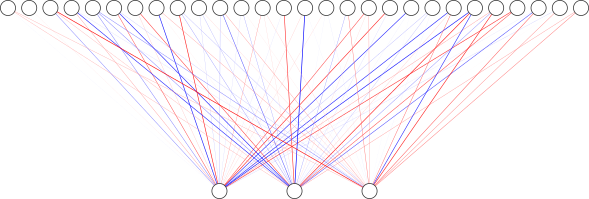

## 🪄 Lancer l'entrainement

Nous avons un modèle initialisé, mais comment apprend t-il ? Tout comme les étudiants sont évalués par des tests, nous devons donner au réseau une fonction qui "note" sa performance. Un telle fonction est appelée une fonction de perte ou `loss` function.

Dans notre cas, nous allons utiliser une fonction spécifique à la classification appelée [SparseCategoricalCrossentropy](https://www.tensorflow.org/api_docs/python/tf/keras/losses/SparseCategoricalCrossentropy):
* **Sparse** - ou éparse, pour cette fonction, cela fait référence au fait que les labels sont représentés par des entiers, associés aux différentes catégories
* **Categorical** - ou catégorielle, cette fonction est faite pour la  classification
* **Cross-entropy** - ou entropie croisée, fait notre modèle plus robuste, en faisant un score faible lorsqu'il fait une erreur de décision. Si un réseau est confiant à 100% alors qu'il se trompe, il aura un score de moins l'infini !
* `from_logits` - la sortie du réseau sera transformée en probabilité, qui peut être interprétée comme la confiance du modèle qu'une catégorie particulière est correcte pour une entrée donnée.

Ce type de loss function fonctionne bien dans notre projet car elle évalue chaque neurone individuellement. Si tous les neurones donnent un signal fort qu'ils sont le label correct, on doit leurs dire qu'ils ne peuvent avoir tous raison !

Pour nous humains, nous pouvons ajouter des métriques ou `metrics` pour s'assurer de la qualité d'apprentissage du modèle. Par exemple, peut-être que la fonction de perte est basse, mais que dire si la justesse du modèle (ou `accuracy`) n'est pas très élevée ?

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

## ✅ Evaluer le réseau

C'est le moment de vérité ! La commande [fit](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit) ci-dessous fera apprendre le modèle, et testera ses connaissances.

Une `epoch` est une revue complète de la base d'images. On présente ainsi au modèle le même exemple de nombreuses fois afin qu'il assimile correctement comment bien les catégoriser.

Regardons comment il travaille dur et cherche à s'améliorer !

In [ ]:
history = model.fit(
    dataset_animals,
    epochs=10,
    verbose=True,
)

Alors, quel est le verdict ? Pas une performance optimale, mais n'oublions pas que ce modèle a peu de neurones pour apprendre, alors que nous humains en avons des milliards !

La justesse ou `accuracy`devrait être autour des 70%, bien que certaines variations aléatoires peuvent arriver à cause du tirage au sort des images à présenter au modèle, de plus les poids du modèle sont aussi initialisés de manière aléatoire.

### Prédiction

Il est temps de tester notre réseau, et de voir ce qu'il a retenu ! On peut utiliser la méthode [predict](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict) pour voir si les sorties du modèle à partir d'un ensemble d'images (ou `batch`) sont correctes.

Ci-dessous, on peut calculer la prédiction du modèle avec une image tirée au sort de notre base d'apprentissage.

In [ ]:
# Tirage au sort d'une image comme précédemment
for images, labels in dataset_animals.take(1):

    image = images[0].numpy().astype("uint8")
    label = labels[0].numpy()

    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

# Construction d'un batch
image_batch = tf.expand_dims(image, axis=0)

# Prédiction
prediction = model.predict(image_batch)
print(prediction)

Ce sont les résultats bruts, et ils nécessitent du formattage pour être interprétés plus facilement par un humain. Ainsi, ci-dessous, on affiche un tracé des calculs obtenus par les neurones de sortie. Plus la valeur est grande et plus le neurone est sûr qu'il correspond à la classe correct (et inversement, plus la valeur est petite, et plus le neurone est sûr qu'il n'est **pas** la classe correcte).

Pour rappel, voici la table des catégories d'animaux de la base :

| Label | Description (en) | Description (fr) |
| --- | --- | --- |
| 0 | Cat | Chat |
| 1 | Dog | Chien |
| 2 | Horse | Cheval |

In [ ]:
x_values = range(3)
plt.figure()
plt.bar(x_values, prediction.flatten())
plt.xticks(range(3), labels=class_names)
plt.show()

# 🎬 Conclusion

Félicitations ! Le notebook est terminé ! Bien entendu, le modèle n'est pas très performant, et a encore du chemin pour faire mieux que les humains. N'hésitez pas à en apprendre plus sur l'IA et les modèles qui permettent de traiter des images ou toute autre sorte de donnée !

# Licence


[![License: CC BY-NC-SA 4.0](https://img.shields.io/badge/License-CC%20BY--NC--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-nc-sa/4.0/)

Copyright © 2026 [NXV](https://nxv.fr).

Cette ressource est sous licence 
[Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License](https://creativecommons.org/licenses/by-nc-sa/4.0/).
